In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow import keras

df = pd.read_csv("/content/drive/MyDrive/Colab Notebooks/diabetes.csv")
df

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
...,...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1


In [4]:
y=df['Outcome']
X=df.drop('Outcome', axis =1)

In [5]:
from sklearn.model_selection import train_test_split

X1_train,X1_test, y1_train,y1_test = train_test_split(X,y,test_size=0.2,random_state=0)

In [6]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.ensemble import RandomForestClassifier
import warnings

clf_lr = LogisticRegression(random_state=0)
clf_lr.fit(X1_train, y1_train)

pred_lr = clf_lr.predict(X1_test)

print ("\n--- Logistic Regression Classifier ---")
print (accuracy_score(y1_test, pred_lr))
print (confusion_matrix(y1_test, pred_lr))



--- Logistic Regression Classifier ---
0.8246753246753247
[[98  9]
 [18 29]]


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [7]:
clf_dt1 = DecisionTreeClassifier(random_state=0)
clf_dt1.fit(X1_train, y1_train)

pred_dt = clf_dt1.predict(X1_test)

print ("\n--- Decision Tree Classifier ---")
print (accuracy_score(y1_test, pred_dt))
print (confusion_matrix(y1_test, pred_dt))


--- Decision Tree Classifier ---
0.7662337662337663
[[87 20]
 [16 31]]


In [8]:
print ("\n--- Radom Forest ---")
rf_clf1 = RandomForestClassifier(random_state=0)
rf_clf1.fit(X1_train, y1_train)
pred = rf_clf1.predict(X1_test)
print(accuracy_score(y1_test,pred))
print (confusion_matrix(y1_test, pred))


--- Radom Forest ---
0.7857142857142857
[[92 15]
 [18 29]]


In [9]:
df2 = df.drop('Outcome', axis=1)
df2

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age
0,6,148,72,35,0,33.6,0.627,50
1,1,85,66,29,0,26.6,0.351,31
2,8,183,64,0,0,23.3,0.672,32
3,1,89,66,23,94,28.1,0.167,21
4,0,137,40,35,168,43.1,2.288,33
...,...,...,...,...,...,...,...,...
763,10,101,76,48,180,32.9,0.171,63
764,2,122,70,27,0,36.8,0.340,27
765,5,121,72,23,112,26.2,0.245,30
766,1,126,60,0,0,30.1,0.349,47


In [11]:
y1=df2['BMI']
X1 = df2.drop('BMI',axis =1)

In [12]:
X1_train, X1_test, y1_train, y1_test = train_test_split(X1, y1,test_size=0.25,random_state=0)

In [13]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

model = LinearRegression()
model.fit(X1_train, y1_train)
ly_preds = model.predict(X1_test)

print('평균제곱근오차', mean_squared_error(ly_preds, y1_test))

def mse_np(actual, predicted):
    return np.mean((np.array(actual) - np.array(predicted)) ** 2)

print('평균제곱근오차', mse_np(ly_preds, y1_test))

def mse(actual, predicted):
    sum_square_error = sum((a - p) ** 2 for a, p in zip(actual, predicted))
    mean_square_error = sum_square_error / len(actual)
    return mean_square_error

print('평균제곱근오차', mse(ly_preds, y1_test))

평균제곱근오차 52.23558099742443
평균제곱근오차 52.23558099742443
평균제곱근오차 52.23558099742445


In [14]:
from sklearn.tree import DecisionTreeRegressor

model = DecisionTreeRegressor()
model.fit(X1_train, y1_train)

from sklearn.metrics import mean_squared_error

dy_preds = model.predict(X1_test)
print('평균제곱근오차', mean_squared_error(dy_preds, y1_test))

평균제곱근오차 67.68739583333333


In [15]:
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor()
model.fit(X1_train, y1_train)

from sklearn.metrics import mean_squared_error

ry_preds = model.predict(X1_test)
print('평균제곱근오차', mean_squared_error(ry_preds, y1_test))

평균제곱근오차 46.007597760416694


In [17]:
from tensorflow.keras import layers, models

Y = pd.get_dummies(y).values
X = X.values

In [18]:
X_train,X_test, y_train,y_test = train_test_split(X,Y,test_size=0.2,random_state=0)


In [20]:
model = models.Sequential([
    layers.Dense(64, activation="relu", input_shape=(X.shape[1],)),
    layers.Dropout(0.3),
    layers.Dense(32, activation="relu"),
    layers.Dense(Y.shape[1], activation="sigmoid")   # 클래스 수 맞춤
])

model.compile(
    optimizer="adam",
    loss="binary_crossentropy",   # one-hot이면 categorical_crossentropy
    metrics=["accuracy"]
)

history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=50,
    batch_size=16,
    verbose=1
)

Epoch 1/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 8ms/step - accuracy: 0.5438 - loss: 5.5820 - val_accuracy: 0.6423 - val_loss: 2.4495
Epoch 2/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5336 - loss: 3.9150 - val_accuracy: 0.6911 - val_loss: 1.4037
Epoch 3/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5906 - loss: 2.8366 - val_accuracy: 0.6829 - val_loss: 1.2705
Epoch 4/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5662 - loss: 2.4934 - val_accuracy: 0.6260 - val_loss: 1.0478
Epoch 5/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.5886 - loss: 2.1180 - val_accuracy: 0.4553 - val_loss: 1.0539
Epoch 6/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5764 - loss: 1.6445 - val_accuracy: 0.6667 - val_loss: 0.8256
Epoch 7/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6029 - loss: 1.6139 - val_accuracy: 0.6341 - val_loss: 0.7907
Epoch 8/50
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6049 - loss: 1.4192 - val_accuracy: 0.6098 - val_loss:

In [21]:
y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test, axis=1)
y_pred_class = np.argmax(y_pred, axis=1)

# 학습 곡선
loss = history.history['loss']
val_loss = history.history['val_loss']
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']


y_pred = model.predict(X_test)

y_test_class = np.argmax(y_test,axis=1)
y_pred_class = np.argmax(y_pred,axis=1)

5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 24ms/step
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


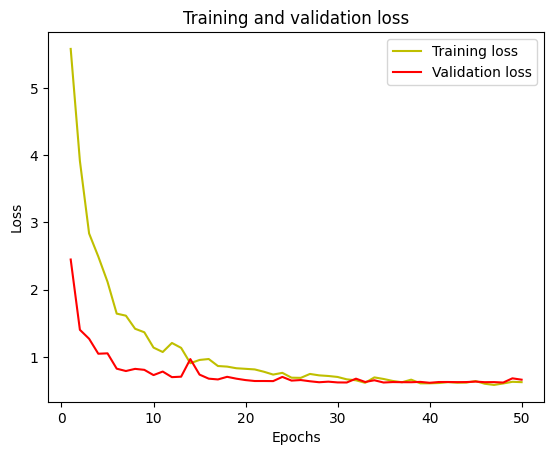

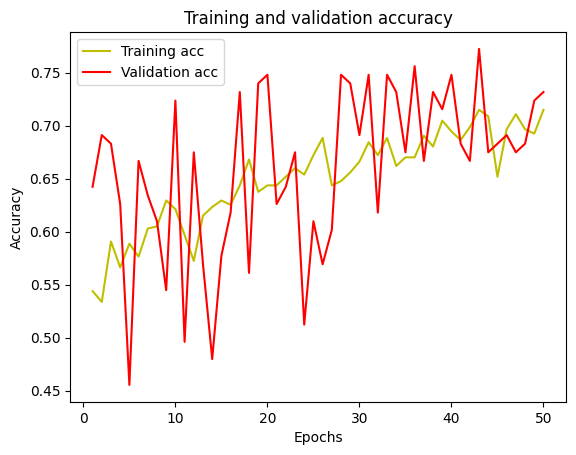

In [22]:
import matplotlib.pyplot as plt
import seaborn as sns

loss = history.history['loss']
val_loss= history.history['val_loss']
epochs = range(1, len(loss) + 1)
plt.plot(epochs, loss, 'y', label='Training loss')
plt.plot(epochs, val_loss, 'r', label='Validation loss')
plt.title('Training and validation loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.show()

acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
plt.plot(epochs, acc, 'y', label='Training acc')
plt.plot(epochs, val_acc, 'r', label='Validation acc')
plt.title('Training and validation accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


In [23]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_class,y_pred_class))
print(confusion_matrix(y_test_class,y_pred_class))

              precision    recall  f1-score   support

           0       0.74      0.93      0.83       107
           1       0.63      0.26      0.36        47

    accuracy                           0.73       154
   macro avg       0.69      0.59      0.60       154
weighted avg       0.71      0.73      0.69       154

[[100   7]
 [ 35  12]]
